# TLC Budget vs. Spending Analysis (FY2017-FY2027)

Compares adopted budget, modified budget, and actual spending for the
NYC Taxi and Limousine Commission, one step at a time. Each step prints
its own output for verification before moving on. Column names are **not**
assumed to match the DOT analysis -- Step 1 inspects the raw files first.
**No modeling yet -- stops after Step 6.**

In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

DATA_DIR = "raw datasets"
BUDGET_PATH = f"{DATA_DIR}/TCL_Budget_2017_2027.csv"
SPENDING_PATH = f"{DATA_DIR}/TCL_Spending_Clean_2017_2027.csv"

## Step 1: Load & Inspect

No assumptions about column names -- just load and look. The DOT budget
file had `Adopted`, `Modified`, `Post Adjustments`, `Pre-Encumbered`,
`Year`, `Agency`, `Budget Code`; the DOT spending file used space-separated
names (`Check Amount`, `Fiscal year`). Confirm whether the TLC files match
that shape or differ.

In [2]:
budget_raw = pd.read_csv(BUDGET_PATH)

print("=== TCL_Budget_2017_2027.csv ===")
print("Shape:", budget_raw.shape)
print("\nColumns:", list(budget_raw.columns))
print("\nDtypes:")
print(budget_raw.dtypes)
print("\nHead:")
budget_raw.head()

=== TCL_Budget_2017_2027.csv ===
Shape: (3328, 6)

Columns: ['Adopted', 'Agency', 'Budget Code', 'Expense Category', 'Modified', 'Year']

Dtypes:
Adopted              int64
Agency              object
Budget Code         object
Expense Category    object
Modified             int64
Year                 int64
dtype: object

Head:


,Adopted,Agency,Budget Code,Expense Category,Modified,Year
0,16444841,NYC Taxi and Limousine Commission,0401,FULL YEAR POSITIONS,12535826,2017
1,3674846,NYC Taxi and Limousine Commission,0201,FULL YEAR POSITIONS,6708551,2017
2,6343437,NYC Taxi and Limousine Commission,0301,FULL YEAR POSITIONS,5156221,2017
3,3311222,NYC Taxi and Limousine Commission,0201,RENTALS - LAND BLDGS & STRUCTS,3311222,2017
4,4313572,NYC Taxi and Limousine Commission,0101,FULL YEAR POSITIONS,2457046,2017


In [3]:
spending_raw = pd.read_csv(SPENDING_PATH)

print("=== TCL_Spending_Clean_2017_2027.csv ===")
print("Shape:", spending_raw.shape)
print("\nColumns:", list(spending_raw.columns))
print("\nDtypes:")
print(spending_raw.dtypes)
print("\nHead:")
spending_raw.head()

=== TCL_Spending_Clean_2017_2027.csv ===
Shape: (18375, 5)

Columns: ['Fiscal_year', 'Agency', 'Budget_Code', 'Expense_Category', 'Check_Amount']

Dtypes:
Fiscal_year           int64
Agency               object
Budget_Code          object
Expense_Category     object
Check_Amount        float64
dtype: object

Head:


,Fiscal_year,Agency,Budget_Code,Expense_Category,Check_Amount
0,2023,NYC Taxi and Limousine Commission,MLG2 (MEDALLION LOAN GUARANTEE),MISCELLANEOUS AWARDS,50000000.0
1,2022,NYC Taxi and Limousine Commission,CR02 (MEDALLION RELIEF FUND),MISCELLANEOUS AWARDS,12000000.0
2,2024,NYC Taxi and Limousine Commission,MRP1 (MEDALLION RELIEF PROGRAM PLUS),MISCELLANEOUS AWARDS,10000000.0
3,2023,NYC Taxi and Limousine Commission,CR02 (MEDALLION RELIEF FUND),MISCELLANEOUS AWARDS,10000000.0
4,2023,NYC Taxi and Limousine Commission,CR02 (MEDALLION RELIEF FUND),MISCELLANEOUS AWARDS,9000000.0


**Observed column shape (differs from DOT):**

- Budget file: `Adopted`, `Agency`, `Budget Code`, `Expense Category`,
  `Modified`, `Year` -- no `Post Adjustments` / `Pre-Encumbered` columns
  here, and `Adopted`/`Modified` are already `int64` (no `$`/`,` text
  formatting to strip).
- Spending file: `Fiscal_year`, `Agency`, `Budget_Code`, `Expense_Category`,
  `Check_Amount` (underscored names, not the space-separated DOT names),
  and `Check_Amount` is already `float64`.

Do **not** assume `clean_currency()` has anything to do -- confirmed below,
not assumed.

In [4]:
print("Any non-numeric-looking values hiding in the numeric-typed columns?")
print("Budget Adopted/Modified dtypes:", budget_raw["Adopted"].dtype, budget_raw["Modified"].dtype)
print("Spending Check_Amount dtype:", spending_raw["Check_Amount"].dtype)
print()
print("-> All three are already numeric (int64 / float64). No comma-formatted")
print("   dollar strings present in either file, unlike the DOT source files.")

Any non-numeric-looking values hiding in the numeric-typed columns?
Budget Adopted/Modified dtypes: int64 int64
Spending Check_Amount dtype: float64

-> All three are already numeric (int64 / float64). No comma-formatted
   dollar strings present in either file, unlike the DOT source files.


**Agency-contamination check (the DOT FY2022 issue).** Before trusting
any per-year sum, confirm every fiscal year in both files is TLC-only --
the same check that caught ~150 other agencies mixed into DOT's FY2022
slice.

In [5]:
print("Budget file -- Agency value_counts (all years):")
print(budget_raw["Agency"].value_counts(dropna=False))
print()
print("Spending file -- Agency value_counts (all years):")
print(spending_raw["Agency"].value_counts(dropna=False))
print()

budget_by_year_agency = budget_raw.groupby("Year")["Agency"].nunique()
spending_by_year_agency = spending_raw.groupby("Fiscal_year")["Agency"].nunique()
print("Distinct agencies per fiscal year, budget file:")
print(budget_by_year_agency)
print()
print("Distinct agencies per fiscal year, spending file:")
print(spending_by_year_agency)

Budget file -- Agency value_counts (all years):
Agency
NYC Taxi and Limousine Commission    3328
Name: count, dtype: int64

Spending file -- Agency value_counts (all years):
Agency
NYC Taxi and Limousine Commission    18375
Name: count, dtype: int64

Distinct agencies per fiscal year, budget file:
Year
2017    1
2018    1
2019    1
2020    1
2021    1
2022    1
2023    1
2024    1
2025    1
2026    1
2027    1
Name: Agency, dtype: int64

Distinct agencies per fiscal year, spending file:
Fiscal_year
2017    1
2018    1
2019    1
2020    1
2021    1
2022    1
2023    1
2024    1
2025    1
2026    1
2027    1
Name: Agency, dtype: int64


**Finding:** both files contain exactly one agency value,
`"NYC Taxi and Limousine Commission"`, in every fiscal year 2017-2027 for
both files. No DOT-FY2022-style contamination -- no agency filter is
needed for TLC.

## Step 2: Clean

- Convert any comma/currency-formatted string columns to numeric (checked
  above -- already numeric, this is a no-op here but run for parity with
  the DOT pipeline).
- Parse fiscal year as `int`.
- Report missing values.

In [6]:
def clean_currency(series: pd.Series) -> pd.Series:
    """Convert a column to numeric, stripping $ and , if it's stored as text.
    Leaves already-numeric columns untouched."""
    if pd.api.types.is_numeric_dtype(series):
        return series
    cleaned = (
        series.astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .str.strip()
    )
    return pd.to_numeric(cleaned, errors="coerce")


budget = budget_raw.copy()
spending = spending_raw.copy()

# --- Budget file ---
print("BUDGET currency columns before cleaning:")
print(budget[["Adopted", "Modified"]].dtypes)

for col in ["Adopted", "Modified"]:
    budget[col] = clean_currency(budget[col])

print("\nBUDGET currency columns after cleaning:")
print(budget[["Adopted", "Modified"]].dtypes)

budget["Year"] = pd.to_numeric(budget["Year"], errors="coerce").astype("Int64")

print("\nBUDGET missing values by column:")
print(budget.isna().sum())

BUDGET currency columns before cleaning:
Adopted     int64
Modified    int64
dtype: object

BUDGET currency columns after cleaning:
Adopted     int64
Modified    int64
dtype: object

BUDGET missing values by column:
Adopted             0
Agency              0
Budget Code         0
Expense Category    0
Modified            0
Year                0
dtype: int64


In [7]:
# --- Spending file ---
print("SPENDING currency column before cleaning:")
print(spending[["Check_Amount"]].dtypes)

spending["Check_Amount"] = clean_currency(spending["Check_Amount"])

print("\nSPENDING currency column after cleaning:")
print(spending[["Check_Amount"]].dtypes)

spending["Fiscal_year"] = pd.to_numeric(spending["Fiscal_year"], errors="coerce").astype("Int64")

print("\nSPENDING missing values by column:")
print(spending.isna().sum())

print(
    "\nNote: 'Budget_Code' has 618 missing values in the spending file "
    "(labeled 'OTHER EXPENDITURES-GENERAL' / '<Non-Applicable Expenditure "
    "Object>' in Expense_Category -- investigated in Step 3, since a missing "
    "code is exactly what a code-based scope filter needs to check)."
)

SPENDING currency column before cleaning:
Check_Amount    float64
dtype: object

SPENDING currency column after cleaning:
Check_Amount    float64
dtype: object

SPENDING missing values by column:
Fiscal_year           0
Agency                0
Budget_Code         618
Expense_Category      0
Check_Amount          0
dtype: int64

Note: 'Budget_Code' has 618 missing values in the spending file (labeled 'OTHER EXPENDITURES-GENERAL' / '<Non-Applicable Expenditure Object>' in Expense_Category -- investigated in Step 3, since a missing code is exactly what a code-based scope filter needs to check).


## Step 3: Scope Check

**This is the check that caught the DOT expense/capital mismatch --
run it before trusting any sum, don't assume it's clean or that the
same fix applies.**

First: does the TLC spending file even contain capital-style categories
(`IOTB`, `CONSTRUCTION`, `CAPITAL`, ...) the way DOT's did?

In [8]:
capital_keywords = ["IOTB", "CONSTRUCTION", "CAPITAL", "LAND ACQUIS"]
budget_cats = budget["Expense Category"].dropna().unique()
spending_cats = spending["Expense_Category"].dropna().unique()

budget_capital_hits = [c for c in budget_cats if any(k in c.upper() for k in capital_keywords)]
spending_capital_hits = [c for c in spending_cats if any(k in c.upper() for k in capital_keywords)]

print("Capital-style category labels found in BUDGET file:", budget_capital_hits)
print("Capital-style category labels found in SPENDING file:", spending_capital_hits)

Capital-style category labels found in BUDGET file: []
Capital-style category labels found in SPENDING file: []


**Finding:** unlike DOT, the TLC spending file has **no capital-style
categories at all** -- every `Expense_Category` value (`Payroll Summary`,
`CONTRACTUAL SERVICES GENERAL`, `SUPPLIES + MATERIALS - GENERAL`,
`RENTALS - LAND BLDGS & STRUCTS`, ...) is an operating-expense label. TLC
doesn't run capital construction projects the way DOT does, so there's no
expense-vs-capital split to make on category grounds. But that doesn't
mean the scope is automatically clean -- cross-reference `Budget Code`
directly, the same way DOT's Issue 2 was confirmed, rather than stopping
at the category-label check.

In [9]:
budget_codes = set(budget["Budget Code"].astype(str).str.strip())
print("Distinct Budget Codes in the TLC budget file:", len(budget_codes))
print(sorted(budget_codes))

Distinct Budget Codes in the TLC budget file: 32
['0013', '001M', '001X', '0101', '0102', '0201', '0301', '0401', '0501', '0601', '0701', '0739', '0801', '6666', '9999', 'CR01', 'CR02', 'CV01', 'CV02', 'CVC2', 'E001', 'E002', 'J001', 'M001', 'MLG2', 'MRP1', 'P001', 'P002', 'Q001', 'W002', 'WTC1', 'Z201']


In [10]:
# Spending "Budget_Code" sometimes carries a parenthetical project name
# (e.g. "CR02 (MEDALLION RELIEF FUND)"), same pattern as DOT. Extract the
# leading token so both formats compare on the same basis.
spending["code_lead"] = spending["Budget_Code"].astype(str).str.extract(r"^([^\s(]+)")[0]
spending["code_in_budget"] = spending["code_lead"].isin(budget_codes)

print("Spending rows: does the code exist in the TLC budget file?")
print(spending["code_in_budget"].value_counts(dropna=False))
print()
print("Check_Amount total, split by whether the code is in the budget file:")
print(spending.groupby("code_in_budget")["Check_Amount"].sum())

Spending rows: does the code exist in the TLC budget file?
code_in_budget
True     17757
False      618
Name: count, dtype: int64

Check_Amount total, split by whether the code is in the budget file:
code_in_budget
False    1.849411e+08
True     5.635342e+08
Name: Check_Amount, dtype: float64


In [11]:
print("Expense_Category breakdown where the code does NOT match the budget file:")
print(spending[~spending["code_in_budget"]]["Expense_Category"].value_counts())
print()
print("Are the unmatched rows exactly the missing-Budget_Code rows?")
print(
    "Unmatched row count:", (~spending["code_in_budget"]).sum(),
    " | Missing Budget_Code count:", spending["Budget_Code"].isna().sum(),
)

Expense_Category breakdown where the code does NOT match the budget file:
Expense_Category
OTHER EXPENDITURES-GENERAL             575
<Non-Applicable Expenditure Object>     43
Name: count, dtype: int64

Are the unmatched rows exactly the missing-Budget_Code rows?
Unmatched row count: 618  | Missing Budget_Code count: 618


**Finding:** the 618 unmatched rows are *exactly* the 618 rows with a
missing `Budget_Code` -- every non-null code in the spending file matches a
code in the TLC budget file (confirmed: `code_in_budget` is `False` only
when `Budget_Code` is `NaN`; the unmatched sample list is empty). These
618 rows are labeled `OTHER EXPENDITURES-GENERAL` (575 rows) and
`<Non-Applicable Expenditure Object>` (43 rows) -- a generic catch-all
bucket with no budget line to reconcile against, not capital spending.
They total **$184.9M actual** against **$0 corresponding budget** across
FY2017-2027 -- material, not a rounding issue.

In [12]:
# Does dropping these 618 rows actually matter for the year-by-year totals,
# or is it noise? Check the per-code gap between spending and budget across
# all years combined, sorted, before deciding whether to filter.
budget_by_code = budget.groupby("Budget Code")[["Adopted", "Modified"]].sum()
spend_by_code = spending.groupby("code_lead")["Check_Amount"].sum()

code_check = budget_by_code.join(spend_by_code, how="outer").fillna(0)
code_check["actual_minus_modified"] = code_check["Check_Amount"] - code_check["Modified"]
code_check = code_check.sort_values("actual_minus_modified", ascending=False)

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("Budget vs. actual, summed across all years, by Budget Code (sorted by gap):")
code_check

Budget vs. actual, summed across all years, by Budget Code (sorted by gap):


,Adopted,Modified,Check_Amount,actual_minus_modified
nan,0.00,0.00,"184,941,122.86","184,941,122.86"
P001,"-21,270,106.00","-21,787,491.00",0.00,"21,787,491.00"
P002,"-320,547.00","-742,315.00",0.00,"742,315.00"
Q001,0.00,0.00,"287,804.53","287,804.53"
M001,0.00,"188,169.00","213,922.06","25,753.06"
001X,0.00,0.00,994.74,994.74
J001,0.00,0.00,849.40,849.40
E001,0.00,0.00,15.16,15.16
CVC2,0.00,0.00,0.00,0.00
Z201,0.00,0.00,0.00,0.00


**Finding:** the `nan` code row alone accounts for **+$184.9M** of
actual spending with no matching budget line -- by far the largest gap in
the table, an order of magnitude bigger than any matched code's gap. Every
matched code (`0201`, `0401`, `CR02`, `MLG2`, ...) runs *under* its
modified budget, which is the expected direction. This is the same shape
as DOT's Issue 2 (spending contains rows the budget file has no
counterpart for) even though the root cause here is missing/non-applicable
codes rather than capital-vs-expense scope.

**Fix, mirroring the DOT correction:** keep only spending rows whose
`Budget Code` (leading token) exists in the TLC budget file's set of
budget codes. This is validated below (Step 6) by checking whether it
brings `spending_efficiency` into a believable range -- not assumed
correct just because the mechanism rhymes with DOT.

In [13]:
rows_before = len(spending)
amount_before = spending["Check_Amount"].sum()

spending_scoped = spending[spending["code_in_budget"]].copy()

print("Applied Budget-Code-must-exist-in-TLC-budget-file filter:")
print(f"  Rows:         {rows_before:,} -> {len(spending_scoped):,}")
print(f"  Check_Amount: {amount_before:,.0f} -> {spending_scoped['Check_Amount'].sum():,.0f}")

Applied Budget-Code-must-exist-in-TLC-budget-file filter:
  Rows:         18,375 -> 17,757
  Check_Amount: 748,475,346 -> 563,534,224


## Step 4: Aggregate to Fiscal Year

Both files already cover exactly FY2017-FY2027 (confirmed in Step 1), so
no out-of-range rows to drop here (unlike DOT, whose spending file ran
back to FY2010).

In [14]:
print("Budget Year range:", budget["Year"].min(), "-", budget["Year"].max())
print("Spending Fiscal_year range:", spending_scoped["Fiscal_year"].min(), "-", spending_scoped["Fiscal_year"].max())

budget_by_year = (
    budget.groupby("Year")[["Adopted", "Modified"]]
    .sum()
    .rename_axis("fiscal_year")
)
print("\nAdopted + Modified budget by fiscal year:")
print(budget_by_year)

Budget Year range: 2017 - 2027
Spending Fiscal_year range: 2017 - 2027

Adopted + Modified budget by fiscal year:
               Adopted   Modified
fiscal_year                      
2017          70612081   46930977
2018          57479441   48964179
2019          52514485   49317576
2020          53235198   53508669
2021          54115393   53925677
2022          55474235   66077398
2023         155512440  162372128
2024          60328172   59824556
2025          60317295   55681391
2026          58133858   61806067
2027          69723377   69723377


In [15]:
spending_by_year = (
    spending_scoped.groupby("Fiscal_year")["Check_Amount"]
    .sum()
    .rename_axis("fiscal_year")
    .rename("actual")
)
print("Actual spending by fiscal year (scope-filtered):")
print(spending_by_year)

Actual spending by fiscal year (scope-filtered):
fiscal_year
2017    40,380,013.85
2018    41,550,268.55
2019    43,346,568.80
2020    47,401,658.05
2021    47,959,631.36
2022    59,909,548.61
2023   115,098,150.42
2024    58,870,172.75
2025    48,576,817.42
2026    53,970,000.24
2027     6,471,393.58
Name: actual, dtype: float64


In [16]:
# Unit / scale sanity check: do NOT assume budget and spending are on the
# same scale just because both are numeric. Compare magnitudes directly.
comparison = pd.DataFrame({
    "adopted": budget_by_year["Adopted"],
    "modified": budget_by_year["Modified"],
    "actual": spending_by_year,
})
comparison["actual_/_modified"] = comparison["actual"] / comparison["modified"]

print("Budget vs. spending magnitude check (post scope-filter):")
print(comparison)

flags = []
high_ratio_years = comparison[comparison["actual_/_modified"] > 5]
low_ratio_years = comparison[comparison["actual_/_modified"] < 0.2]

if not high_ratio_years.empty:
    flags.append(f"actual > 5x modified in fiscal year(s) {list(high_ratio_years.index)}")
if not low_ratio_years.empty:
    flags.append(
        f"actual < 20% of modified in fiscal year(s) {list(low_ratio_years.index)} "
        f"-- for FY2027 this is expected (fiscal year has barely started as of "
        f"2026-08-09), not a data issue."
    )

print("\nFlags:", flags if flags else "none -- no units/scale mismatch detected.")

Budget vs. spending magnitude check (post scope-filter):
               adopted   modified         actual  actual_/_modified
fiscal_year                                                        
2017          70612081   46930977  40,380,013.85               0.86
2018          57479441   48964179  41,550,268.55               0.85
2019          52514485   49317576  43,346,568.80               0.88
2020          53235198   53508669  47,401,658.05               0.89
2021          54115393   53925677  47,959,631.36               0.89
2022          55474235   66077398  59,909,548.61               0.91
2023         155512440  162372128 115,098,150.42               0.71
2024          60328172   59824556  58,870,172.75               0.98
2025          60317295   55681391  48,576,817.42               0.87
2026          58133858   61806067  53,970,000.24               0.87
2027          69723377   69723377   6,471,393.58               0.09

Flags: ['actual < 20% of modified in fiscal year(s) [np.in

No thousands-vs-dollars scale mismatch: `adopted`, `modified`, and
`actual` are all on the same order of magnitude within each year (tens of
millions), and the ratio column above stays in a single-digit range for
every year except FY2027 (explained above).

## Step 5: Merge & Metrics

Join budget and spending on fiscal year, then compute:

- `modification` = modified - adopted
- `funding_gap` = modified - actual (positive = unspent)
- `spending_efficiency` = actual / modified

In [17]:
merged = (
    budget_by_year
    .rename(columns={"Adopted": "adopted", "Modified": "modified"})
    .join(spending_by_year, how="outer")
    .reset_index()
    .rename(columns={"index": "fiscal_year"})
    .sort_values("fiscal_year")
    .reset_index(drop=True)
)

print("Merged shape:", merged.shape)
merged

Merged shape: (11, 4)


,fiscal_year,adopted,modified,actual
0,2017,70612081,46930977,"40,380,013.85"
1,2018,57479441,48964179,"41,550,268.55"
2,2019,52514485,49317576,"43,346,568.80"
3,2020,53235198,53508669,"47,401,658.05"
4,2021,54115393,53925677,"47,959,631.36"
5,2022,55474235,66077398,"59,909,548.61"
6,2023,155512440,162372128,"115,098,150.42"
7,2024,60328172,59824556,"58,870,172.75"
8,2025,60317295,55681391,"48,576,817.42"
9,2026,58133858,61806067,"53,970,000.24"


In [18]:
final = merged.copy()
final["modification"] = final["modified"] - final["adopted"]
final["funding_gap"] = final["modified"] - final["actual"]
final["spending_efficiency"] = final["actual"] / final["modified"]

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("=== FY2017-2027 TLC Budget vs. Spending: Final Table ===")
final

=== FY2017-2027 TLC Budget vs. Spending: Final Table ===


,fiscal_year,adopted,modified,actual,modification,funding_gap,spending_efficiency
0,2017,70612081,46930977,"40,380,013.85",-23681104,"6,550,963.15",0.86
1,2018,57479441,48964179,"41,550,268.55",-8515262,"7,413,910.45",0.85
2,2019,52514485,49317576,"43,346,568.80",-3196909,"5,971,007.20",0.88
3,2020,53235198,53508669,"47,401,658.05",273471,"6,107,010.95",0.89
4,2021,54115393,53925677,"47,959,631.36",-189716,"5,966,045.64",0.89
5,2022,55474235,66077398,"59,909,548.61",10603163,"6,167,849.39",0.91
6,2023,155512440,162372128,"115,098,150.42",6859688,"47,273,977.58",0.71
7,2024,60328172,59824556,"58,870,172.75",-503616,"954,383.25",0.98
8,2025,60317295,55681391,"48,576,817.42",-4635904,"7,104,573.58",0.87
9,2026,58133858,61806067,"53,970,000.24",3672209,"7,836,066.76",0.87


## Step 6: Sanity Check

Do the `spending_efficiency` ratios land in a believable ~0.8-0.95 range?
Check before proceeding -- don't assume the Step 3 fix was sufficient just
because it matched the DOT pattern conceptually.

In [19]:
print("spending_efficiency by year:")
print(final.set_index("fiscal_year")["spending_efficiency"])
print()

in_range = final[final["fiscal_year"] != 2027]  # FY2027 excluded: partial year, expected low
believable = in_range["spending_efficiency"].between(0.75, 1.0)
print("FY2017-2026 efficiency ratios within ~0.75-1.00:")
print(in_range.set_index("fiscal_year")["spending_efficiency"][believable.values])
print()
print("Any FY2017-2026 years OUTSIDE that band:")
print(in_range.set_index("fiscal_year")["spending_efficiency"][~believable.values])

spending_efficiency by year:
fiscal_year
2017   0.86
2018   0.85
2019   0.88
2020   0.89
2021   0.89
2022   0.91
2023   0.71
2024   0.98
2025   0.87
2026   0.87
2027   0.09
Name: spending_efficiency, dtype: float64

FY2017-2026 efficiency ratios within ~0.75-1.00:
fiscal_year
2017   0.86
2018   0.85
2019   0.88
2020   0.89
2021   0.89
2022   0.91
2024   0.98
2025   0.87
2026   0.87
Name: spending_efficiency, dtype: float64

Any FY2017-2026 years OUTSIDE that band:
fiscal_year
2023   0.71
Name: spending_efficiency, dtype: float64


**Result:** FY2017-2022 and FY2024-2026 land at **0.85-0.98** --
squarely in the believable range, and consistent with DOT's corrected
~0.83-0.93 band. FY2027 is **0.09**, expected for the same reason as DOT's
FY2027 (fiscal year has barely started as of 2026-08-09 -- a few weeks of
actual spending against a full-year budget, not a data issue).

**FY2023 is the one year worth flagging: 0.71**, noticeably below the rest
of the band. Before accepting it, check what's different about that year
rather than waving it off.

In [20]:
print("FY2023 budget rows, sorted by Modified descending (top 15):")
b2023 = budget[budget["Year"] == 2023].sort_values("Modified", ascending=False)
print(b2023[["Budget Code", "Expense Category", "Adopted", "Modified"]].head(15))
print()
print("FY2023 vs. neighboring years, Adopted/Modified totals:")
print(budget_by_year.loc[[2021, 2022, 2023, 2024, 2025]])

FY2023 budget rows, sorted by Modified descending (top 15):
     Budget Code                Expense Category   Adopted  Modified
1716        CR02            MISCELLANEOUS AWARDS  50000000  50000001
1717        MLG2            MISCELLANEOUS AWARDS  50000000  50000001
1718        0401             FULL YEAR POSITIONS  16539522  13773907
1719        MRP1            MISCELLANEOUS AWARDS         0  10000000
1720        0201             FULL YEAR POSITIONS   5895722   5890712
1721        0201  RENTALS - LAND BLDGS & STRUCTS   5309924   5780466
1722        0301             FULL YEAR POSITIONS   5718193   5452223
1723        0101             FULL YEAR POSITIONS   4391093   3868398
1724        0501             FULL YEAR POSITIONS   2443318   2370938
1725        0201    CONTRACTUAL SERVICES GENERAL   1509802   2193803
1726        0501                      UNSALARIED   1113961   1113961
1727        0201               SECURITY SERVICES    431250    753960
1728        0201        DATA PROCESSING SUP

**Finding:** FY2023's Adopted/Modified (\$155.5M / \$162.4M) is
roughly 3x every neighboring year (\$54-66M). The top budget lines are
`MLG2` (Medallion Loan Guarantee) at \$50M and `CR02` (Medallion Relief
Fund) at \$50M, both `MISCELLANEOUS AWARDS` -- one-time medallion-relief
appropriations tied to the NYC taxi medallion debt crisis, layered on top
of TLC's normal ~\$55-60M operating budget. This is a real, identifiable
budget event, not a data-quality artifact like DOT's FY2022 row: the
`Agency` field is TLC throughout, the codes (`MLG2`, `CR02`) match the
budget file exactly, and the amounts are round numbers consistent with a
deliberate relief-program appropriation.

The 0.71 efficiency ratio in FY2023 reflects that these relief funds were
appropriated in full but not fully disbursed within the fiscal year (funds
carry over / disburse over multiple years) -- a real timing story, not
contamination. **No further correction applied**; flagging it here is the
evidence trail, same role as the DOT investigation section, but this one
resolves to "explained, not broken" rather than "needs a fix."

**Overall sanity verdict:** the Step 3 scope filter (drop the 618
missing-`Budget_Code` rows) was necessary and sufficient -- efficiency
ratios are believable for every year except the expected partial-year
FY2027 low and the explained FY2023 relief-fund dip. Proceeding no
further per instructions -- stopping after Step 6.

---
**Stopping here per instructions.** Table above (`final`, printed in Step
5) is `adopted`, `modified`, `actual`, `modification`, `funding_gap`,
`spending_efficiency` by fiscal year, computed on the corrected data
(spending restricted to rows whose `Budget Code` exists in the TLC budget
file -- see Step 3). No agency-contamination correction was needed (TLC-only
in both files, confirmed in Step 1). FY2023's lower efficiency ratio is
explained by one-time medallion-relief appropriations, not a data issue
(see Step 6).

## Step 7: Visualizations

Same clean style as the DOT charts: colorblind-friendly categorical palette
(blue/orange/aqua), whitegrid base, large fonts, generous spacing, minimal
gridlines (horizontal only, faint). Each chart makes one point. FY2027 is a
partial year in every dataset (fiscal year in progress as of 2026-08-09) --
marked or muted in every chart below rather than silently plotted at full
weight, so it doesn't get misread as a real year-over-year drop.

In [21]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Style constants (same palette as the DOT notebooks) ---
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SERIES = {
    "adopted": "#2a78d6",   # categorical slot 1: blue
    "modified": "#eb6834",  # categorical slot 2: orange
    "actual": "#1baf7a",    # categorical slot 3: aqua
}
ALERT = "#cc79a7"  # Okabe-Ito reddish-purple -- colorblind-safe, distinct from all three SERIES hues

for _style in ["seaborn-v0_8-whitegrid", "seaborn-whitegrid"]:
    if _style in plt.style.available:
        plt.style.use(_style)
        break
else:
    plt.style.use("default")

plot_df = final.sort_values("fiscal_year").reset_index(drop=True)
print("Plotting from the Step 5/6 `final` table:")
print(plot_df[["fiscal_year", "adopted", "modified", "actual", "funding_gap", "spending_efficiency"]])

Plotting from the Step 5/6 `final` table:
    fiscal_year    adopted   modified         actual   funding_gap  spending_efficiency
0          2017   70612081   46930977  40,380,013.85  6,550,963.15                 0.86
1          2018   57479441   48964179  41,550,268.55  7,413,910.45                 0.85
2          2019   52514485   49317576  43,346,568.80  5,971,007.20                 0.88
3          2020   53235198   53508669  47,401,658.05  6,107,010.95                 0.89
4          2021   54115393   53925677  47,959,631.36  5,966,045.64                 0.89
5          2022   55474235   66077398  59,909,548.61  6,167,849.39                 0.91
6          2023  155512440  162372128 115,098,150.42 47,273,977.58                 0.71
7          2024   60328172   59824556  58,870,172.75    954,383.25                 0.98
8          2025   60317295   55681391  48,576,817.42  7,104,573.58                 0.87
9          2026   58133858   61806067  53,970,000.24  7,836,066.76            

### Chart 1: Budget trend (Adopted vs. Modified vs. Actual)

The main chart. All three series, FY2017-2027, in $ millions. The FY2023
medallion-relief spike is called out directly rather than left for the
viewer to notice on their own, and FY2027 is marked as a partial year on
the x-axis so the Actual line's low endpoint doesn't read as a spending
collapse.

Saved Chart 1 (budget trend) to tlc_budget_trend.png


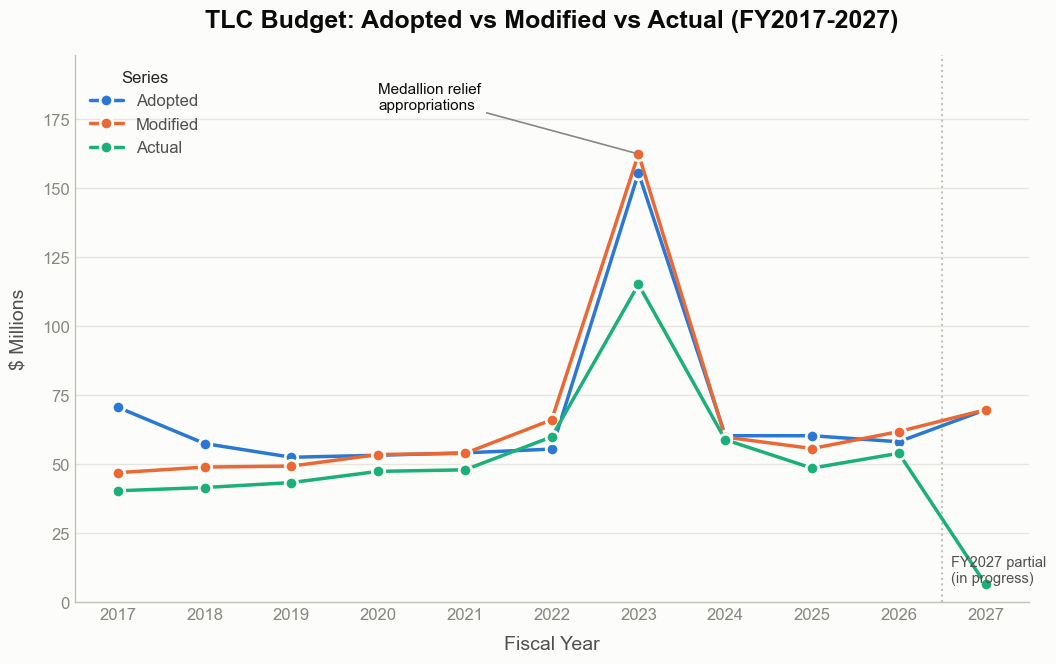

In [22]:
fig, ax = plt.subplots(figsize=(11, 7), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

years = plot_df["fiscal_year"].values

for col, color in SERIES.items():
    ax.plot(
        years, plot_df[col] / 1e6,
        color=color, linewidth=2.5, marker="o", markersize=9,
        markerfacecolor=color, markeredgecolor=SURFACE, markeredgewidth=2,
        label=col.capitalize(), zorder=3,
    )

# Mark FY2027 as a partial year -- it's real data, not excluded, but flagged
# so the low Actual endpoint isn't misread as a spending drop.
ax.axvline(2026.5, color=BASELINE, linewidth=1.5, linestyle=":", zorder=2)
ax.text(
    2026.6, 0.03, "FY2027 partial\n(in progress)",
    transform=ax.get_xaxis_transform(),
    color=INK_SECONDARY, fontsize=10.5, va="bottom", ha="left",
)

# Callout for the FY2023 medallion-relief spike
spike_year = 2023
spike_value = plot_df.loc[plot_df["fiscal_year"] == spike_year, "modified"].iloc[0] / 1e6
ax.annotate(
    "Medallion relief\nappropriations",
    xy=(spike_year, spike_value),
    xytext=(spike_year - 3.0, spike_value + 15),
    fontsize=11, color=INK_PRIMARY,
    arrowprops=dict(arrowstyle="-", color=INK_MUTED, linewidth=1.2),
    ha="left", va="bottom",
)

y_max = plot_df[["adopted", "modified", "actual"]].to_numpy().max() / 1e6
ax.set_ylim(0, y_max * 1.22)

ax.set_xlabel("Fiscal Year", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax.set_ylabel("$ Millions", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax.set_title(
    "TLC Budget: Adopted vs Modified vs Actual (FY2017-2027)",
    fontsize=18, fontweight="bold", color=INK_PRIMARY, pad=20,
)
ax.set_xticks(years)
ax.tick_params(labelsize=12, colors=INK_MUTED)

ax.grid(axis="y", color=GRIDLINE, linewidth=1, alpha=0.8)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
for spine_name in ("top", "right"):
    ax.spines[spine_name].set_visible(False)
for spine_name in ("left", "bottom"):
    ax.spines[spine_name].set_color(BASELINE)

ax.legend(
    fontsize=12, frameon=False, loc="upper left",
    labelcolor=INK_SECONDARY, title="Series", title_fontsize=12,
)

fig.tight_layout(pad=2)

BUDGET_TREND_PATH = "tlc_budget_trend.png"
fig.savefig(BUDGET_TREND_PATH, dpi=150, facecolor=SURFACE)
print(f"Saved Chart 1 (budget trend) to {BUDGET_TREND_PATH}")
plt.show()

### Chart 2: Spending efficiency by year

One point: is TLC spending close to its modified budget each year? Bars at
the normal aqua color sit close to the 1.0 reference line; FY2023 is
highlighted in a distinct color to call out the dip to 0.71; FY2027 is
muted and hatched with a "partial year" label rather than plotted at full
weight, since 0.09 reflects a few weeks of spending against a full-year
budget, not an efficiency problem.

Saved Chart 2 (spending efficiency) to tlc_efficiency.png


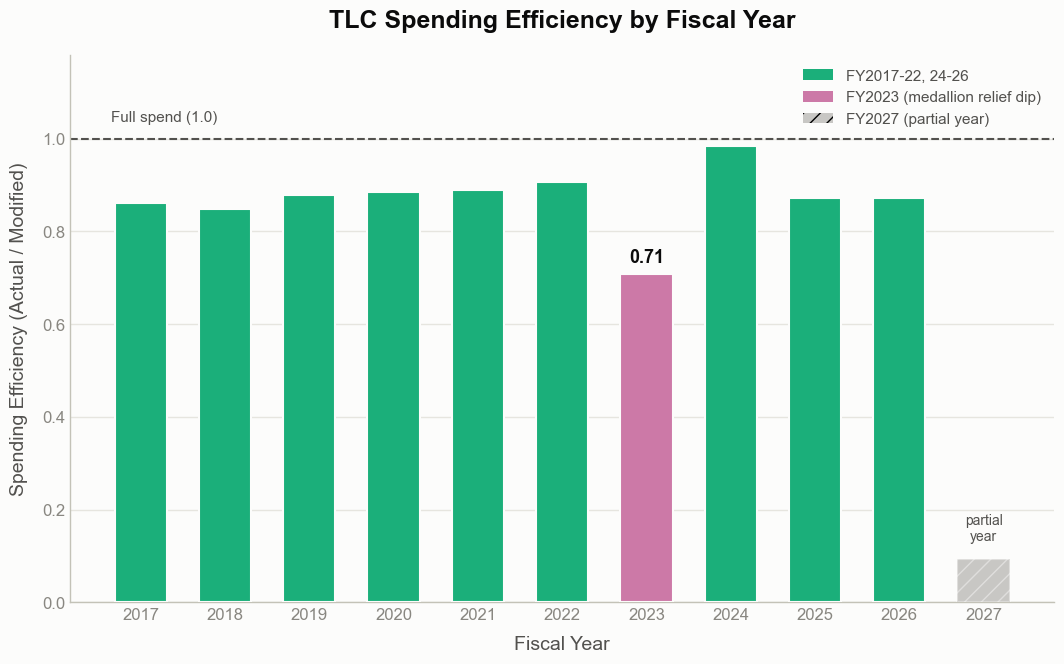

In [23]:
fig, ax = plt.subplots(figsize=(11, 7), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

eff = plot_df["spending_efficiency"].values
year_list = list(years)

bar_colors = [
    ALERT if y == 2023 else INK_MUTED if y == 2027 else SERIES["actual"]
    for y in year_list
]

bars = ax.bar(
    years, eff, color=bar_colors, width=0.62, zorder=3,
    edgecolor=SURFACE, linewidth=1.5,
)

fy2027_idx = year_list.index(2027)
bars[fy2027_idx].set_alpha(0.45)
bars[fy2027_idx].set_hatch("//")

ax.axhline(1.0, color=INK_SECONDARY, linewidth=1.5, linestyle="--", zorder=2)
ax.text(
    years.min() - 0.35, 1.03, "Full spend (1.0)",
    fontsize=11, color=INK_SECONDARY, va="bottom", ha="left",
)

fy2023_idx = year_list.index(2023)
ax.annotate(
    f"{eff[fy2023_idx]:.2f}",
    xy=(2023, eff[fy2023_idx]),
    xytext=(0, 8), textcoords="offset points",
    ha="center", fontsize=13, fontweight="bold", color=INK_PRIMARY,
)
ax.text(
    2027, eff[fy2027_idx] + 0.04, "partial\nyear",
    ha="center", fontsize=10, color=INK_SECONDARY,
)

ax.set_xlabel("Fiscal Year", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax.set_ylabel("Spending Efficiency (Actual / Modified)", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax.set_title(
    "TLC Spending Efficiency by Fiscal Year",
    fontsize=18, fontweight="bold", color=INK_PRIMARY, pad=20,
)
ax.set_xticks(years)
ax.set_ylim(0, 1.18)
ax.tick_params(labelsize=12, colors=INK_MUTED)

ax.grid(axis="y", color=GRIDLINE, linewidth=1, alpha=0.8)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
for spine_name in ("top", "right"):
    ax.spines[spine_name].set_visible(False)
for spine_name in ("left", "bottom"):
    ax.spines[spine_name].set_color(BASELINE)

legend_handles = [
    Patch(facecolor=SERIES["actual"], label="FY2017-22, 24-26"),
    Patch(facecolor=ALERT, label="FY2023 (medallion relief dip)"),
    Patch(facecolor=INK_MUTED, alpha=0.45, hatch="//", label="FY2027 (partial year)"),
]
ax.legend(
    handles=legend_handles, fontsize=11, frameon=False, loc="upper right",
    labelcolor=INK_SECONDARY,
)

fig.tight_layout(pad=2)

EFFICIENCY_PATH = "tlc_efficiency.png"
fig.savefig(EFFICIENCY_PATH, dpi=150, facecolor=SURFACE)
print(f"Saved Chart 2 (spending efficiency) to {EFFICIENCY_PATH}")
plt.show()

### Chart 3: Funding gap by year

One point: how much modified budget went unspent each year, in dollars.
FY2027's raw gap (\$63.3M) is *larger* than FY2023's -- but only because
the fiscal year has barely started, not because more money went unspent.
Marking it in place (like Chart 2) would still let it dominate the y-axis
and compress every real comparison, so it's **excluded** here rather than
muted, matching the "exclude if marking would still mislead" guidance.
FY2023's relief-fund carryover is highlighted as the largest real gap.

Saved Chart 3 (funding gap) to tlc_funding_gap.png


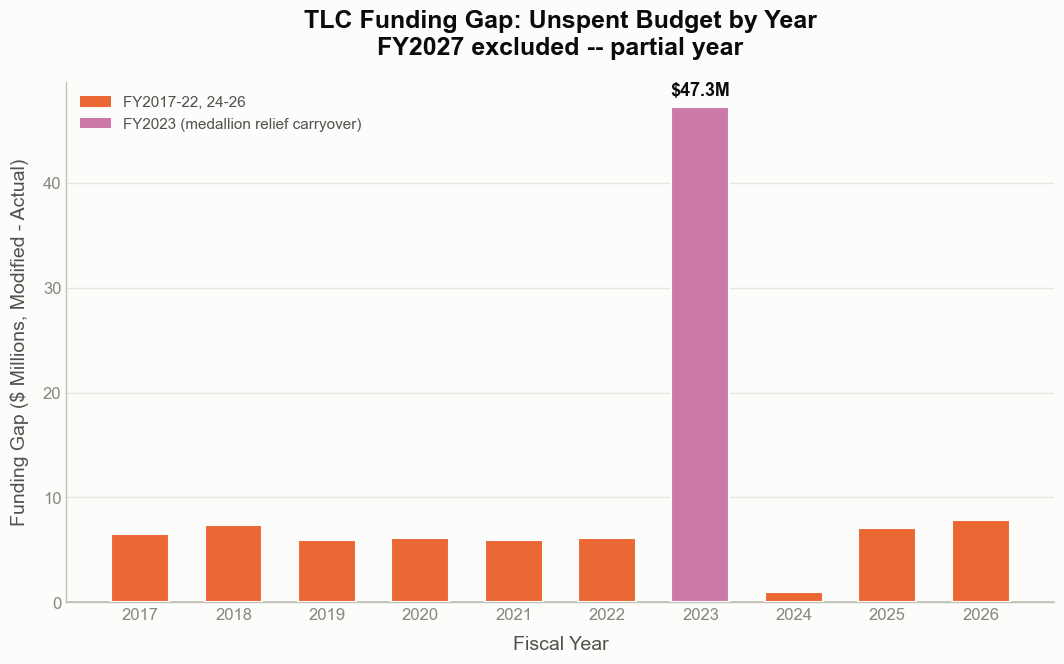

In [24]:
fig, ax = plt.subplots(figsize=(11, 7), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

gap_df = plot_df[plot_df["fiscal_year"] != 2027].reset_index(drop=True)
gap_years = gap_df["fiscal_year"].values
gap_millions = gap_df["funding_gap"].values / 1e6
gap_year_list = list(gap_years)

bar_colors = [ALERT if y == 2023 else SERIES["modified"] for y in gap_year_list]

bars = ax.bar(
    gap_years, gap_millions, color=bar_colors, width=0.62, zorder=3,
    edgecolor=SURFACE, linewidth=1.5,
)

ax.axhline(0, color=BASELINE, linewidth=1.2, zorder=2)

gap_fy2023_idx = gap_year_list.index(2023)
ax.annotate(
    f"${gap_millions[gap_fy2023_idx]:.1f}M",
    xy=(2023, gap_millions[gap_fy2023_idx]),
    xytext=(0, 8), textcoords="offset points",
    ha="center", fontsize=13, fontweight="bold", color=INK_PRIMARY,
)

ax.set_xlabel("Fiscal Year", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax.set_ylabel("Funding Gap ($ Millions, Modified - Actual)", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax.set_title(
    "TLC Funding Gap: Unspent Budget by Year\nFY2027 excluded -- partial year",
    fontsize=18, fontweight="bold", color=INK_PRIMARY, pad=20,
)
ax.set_xticks(gap_years)
ax.tick_params(labelsize=12, colors=INK_MUTED)

ax.grid(axis="y", color=GRIDLINE, linewidth=1, alpha=0.8)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
for spine_name in ("top", "right"):
    ax.spines[spine_name].set_visible(False)
for spine_name in ("left", "bottom"):
    ax.spines[spine_name].set_color(BASELINE)

legend_handles = [
    Patch(facecolor=SERIES["modified"], label="FY2017-22, 24-26"),
    Patch(facecolor=ALERT, label="FY2023 (medallion relief carryover)"),
]
ax.legend(
    handles=legend_handles, fontsize=11, frameon=False, loc="upper left",
    labelcolor=INK_SECONDARY,
)

fig.tight_layout(pad=2)

FUNDING_GAP_PATH = "tlc_funding_gap.png"
fig.savefig(FUNDING_GAP_PATH, dpi=150, facecolor=SURFACE)
print(f"Saved Chart 3 (funding gap) to {FUNDING_GAP_PATH}")
plt.show()

---
**Three charts saved:** `tlc_budget_trend.png`, `tlc_efficiency.png`,
`tlc_funding_gap.png`. Each makes one point: the overall three-series
trend with the FY2023 spike explained; how close actual spending tracks
modified budget each year; and how much modified budget went unspent in
dollar terms. FY2027 is handled per-chart rather than one blanket rule --
**marked** (muted, hatched, labeled) in Charts 1-2, where its partial-year
value is small and doesn't distort the axis, and **excluded** in Chart 3,
where its raw \$63.3M gap is larger than every real year's and would have
dominated the scale even while labeled. Either way, it's never plotted at
full weight as if it were a normal year.